#### Import Libraries

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import AgglomerativeClustering
import seaborn as sns
from collections import Counter

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D
from sklearn.metrics import silhouette_score
import scipy.cluster.hierarchy as shc
from sklearn.manifold import TSNE

#### Import Dataset

In [11]:
%store -r X_cluster_Scaled
%store -r X_x
%store -r y

X = X_x[["Type", "Rotational speed [rpm]", "Torque [Nm]", "Air temperature [K]", "Process temperature [K]", "Tool wear [min]"]]
X = pd.DataFrame(X) 

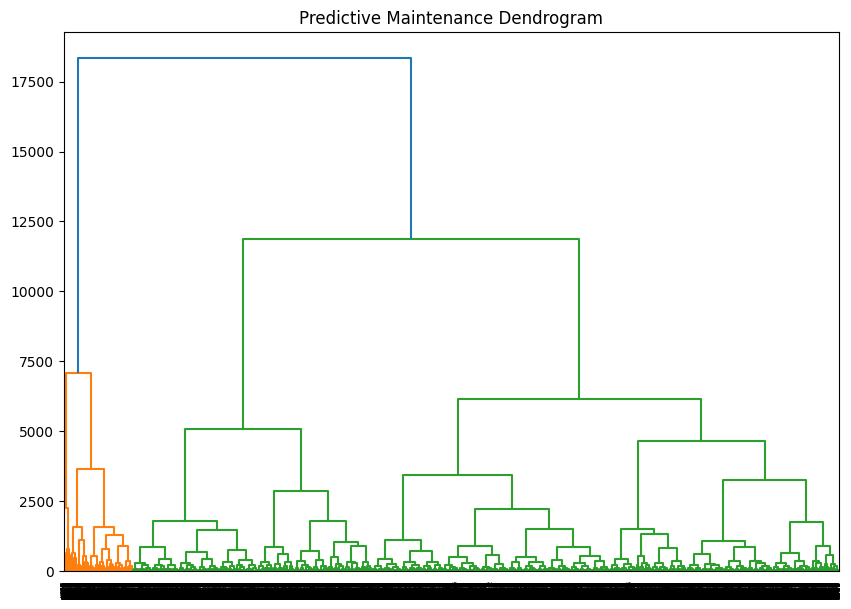

In [12]:
# plot dendogram
plt.figure(figsize=(10, 7))
plt.title("Predictive Maintenance Dendrogram")

# Selecting Annual Income and Spending Scores by index
clusters = shc.linkage(X, method='ward', metric="euclidean")
shc.dendrogram(Z=clusters)
plt.show()

In [13]:
hc_model = AgglomerativeClustering(n_clusters=3, metric='euclidean', linkage='ward')
hc_model.fit_predict(X)
X["hierarchical_cluster"] = hc_model.labels_

cluster_counts = X['hierarchical_cluster'].value_counts()
print(cluster_counts)

hierarchical_cluster
1    6006
2    3083
0     893
Name: count, dtype: int64


In [14]:
if len(X_x) == len(y):
    X_x['hierarchical_cluster'] = hc_model.fit_predict(X_x)

    combined_df = pd.concat([X_x, y.reset_index(drop=True)], axis=1)

    cluster_distribution = combined_df.groupby(['Failure Type', 'hierarchical_cluster']).size().reset_index(name='Count')

    print(cluster_distribution)
else:
    print(f"Mismatch in lengths: X_test_Scaled has {len(X_x)} rows, but y_test has {len(y)} rows.")


    Failure Type  hierarchical_cluster  Count
0            0.0                   0.0     10
1            0.0                   1.0     60
2            0.0                   2.0     42
3            1.0                   0.0    860
4            1.0                   1.0   5809
5            1.0                   2.0   2965
6            2.0                   0.0      6
7            2.0                   1.0     44
8            2.0                   2.0     28
9            3.0                   0.0     13
10           3.0                   1.0     63
11           3.0                   2.0     19
12           4.0                   0.0      2
13           4.0                   1.0     22
14           4.0                   2.0     21


#### Silhouette Coefficient

In [15]:
silhouette_hc = silhouette_score(X.drop(columns=['hierarchical_cluster']), X['hierarchical_cluster'])
print(f'Silhouette Coefficient: {silhouette_hc}')

Silhouette Coefficient: 0.3783241328965026


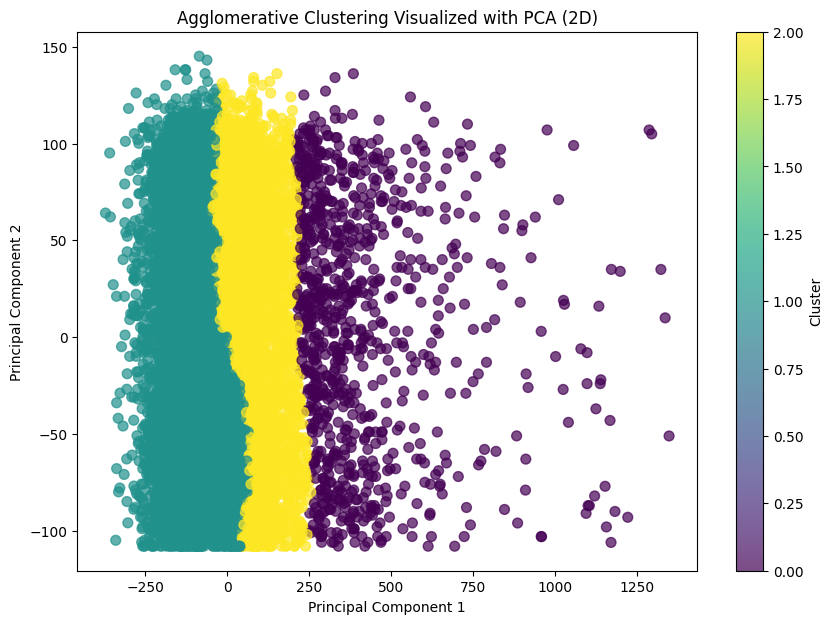

In [16]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X.drop(columns=['hierarchical_cluster']))

plt.figure(figsize=(10, 7))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=X['hierarchical_cluster'], cmap='viridis', s=50, alpha=0.7)
plt.colorbar(label='Cluster')
plt.title("Agglomerative Clustering Visualized with PCA (2D)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

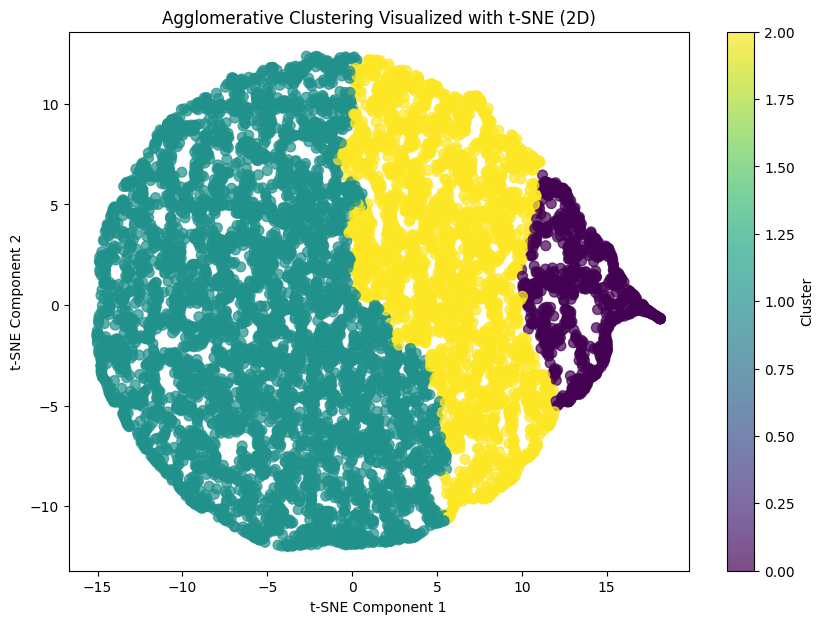

In [17]:
tsne = TSNE(n_components=2, perplexity=30, n_iter=300, random_state=42)
X_tsne = tsne.fit_transform(X.drop(columns=['hierarchical_cluster']))

plt.figure(figsize=(10, 7))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=X['hierarchical_cluster'], cmap='viridis', s=50, alpha=0.7)
plt.colorbar(label='Cluster')
plt.title("Agglomerative Clustering Visualized with t-SNE (2D)")
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.show()

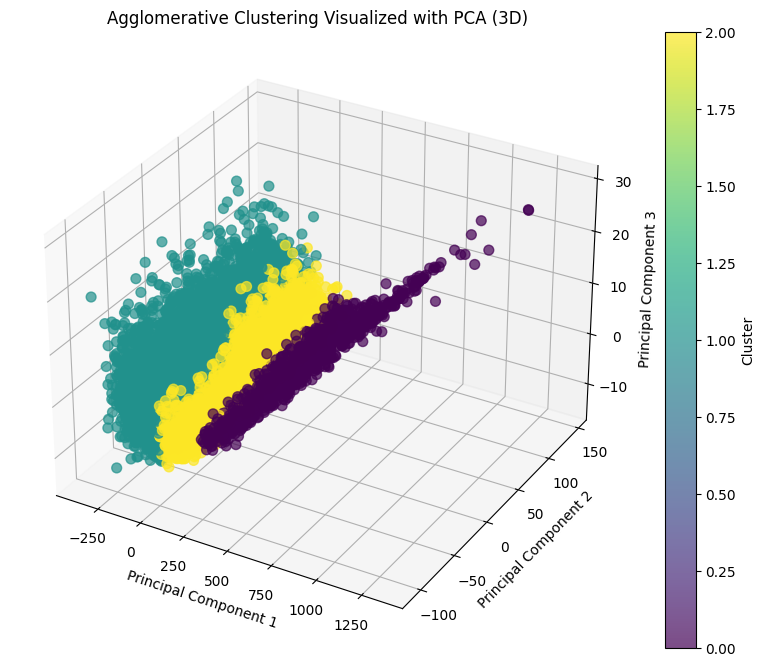

In [18]:
pca = PCA(n_components=3)
X_pca_3d = pca.fit_transform(X.drop(columns=['hierarchical_cluster']))

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(X_pca_3d[:, 0], X_pca_3d[:, 1], X_pca_3d[:, 2], c=X['hierarchical_cluster'], cmap='viridis', s=50, alpha=0.7)

ax.set_title("Agglomerative Clustering Visualized with PCA (3D)")
ax.set_xlabel("Principal Component 1")
ax.set_ylabel("Principal Component 2")
ax.set_zlabel("Principal Component 3")
fig.colorbar(scatter, label='Cluster')
plt.show()

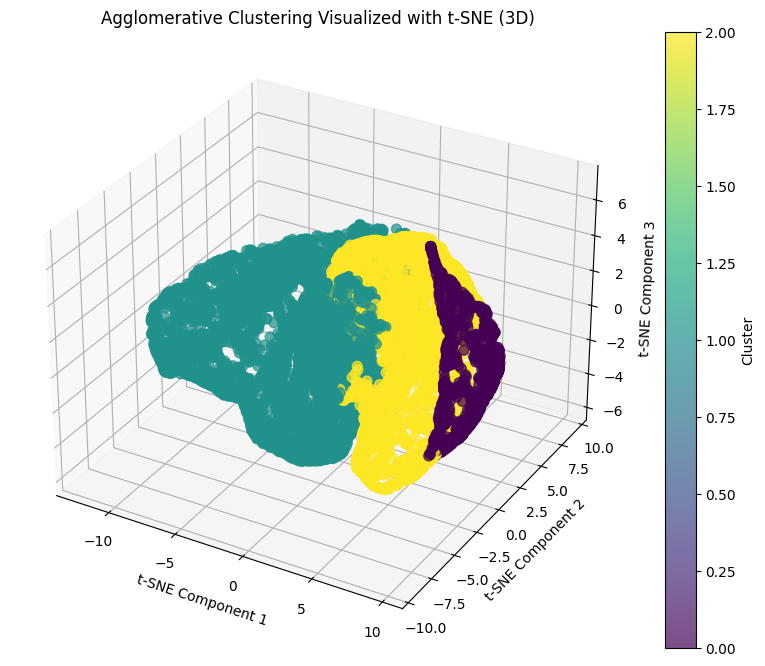

In [19]:
tsne = TSNE(n_components=3, perplexity=30, n_iter=300, random_state=42)
X_tsne_3d = tsne.fit_transform(X.drop(columns=['hierarchical_cluster']))

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(X_tsne_3d[:, 0], X_tsne_3d[:, 1], X_tsne_3d[:, 2], c=X['hierarchical_cluster'], cmap='viridis', s=50, alpha=0.7)

ax.set_title("Agglomerative Clustering Visualized with t-SNE (3D)")
ax.set_xlabel("t-SNE Component 1")
ax.set_ylabel("t-SNE Component 2")
ax.set_zlabel("t-SNE Component 3")
fig.colorbar(scatter, label='Cluster')
plt.show()

<Figure size 1000x800 with 0 Axes>

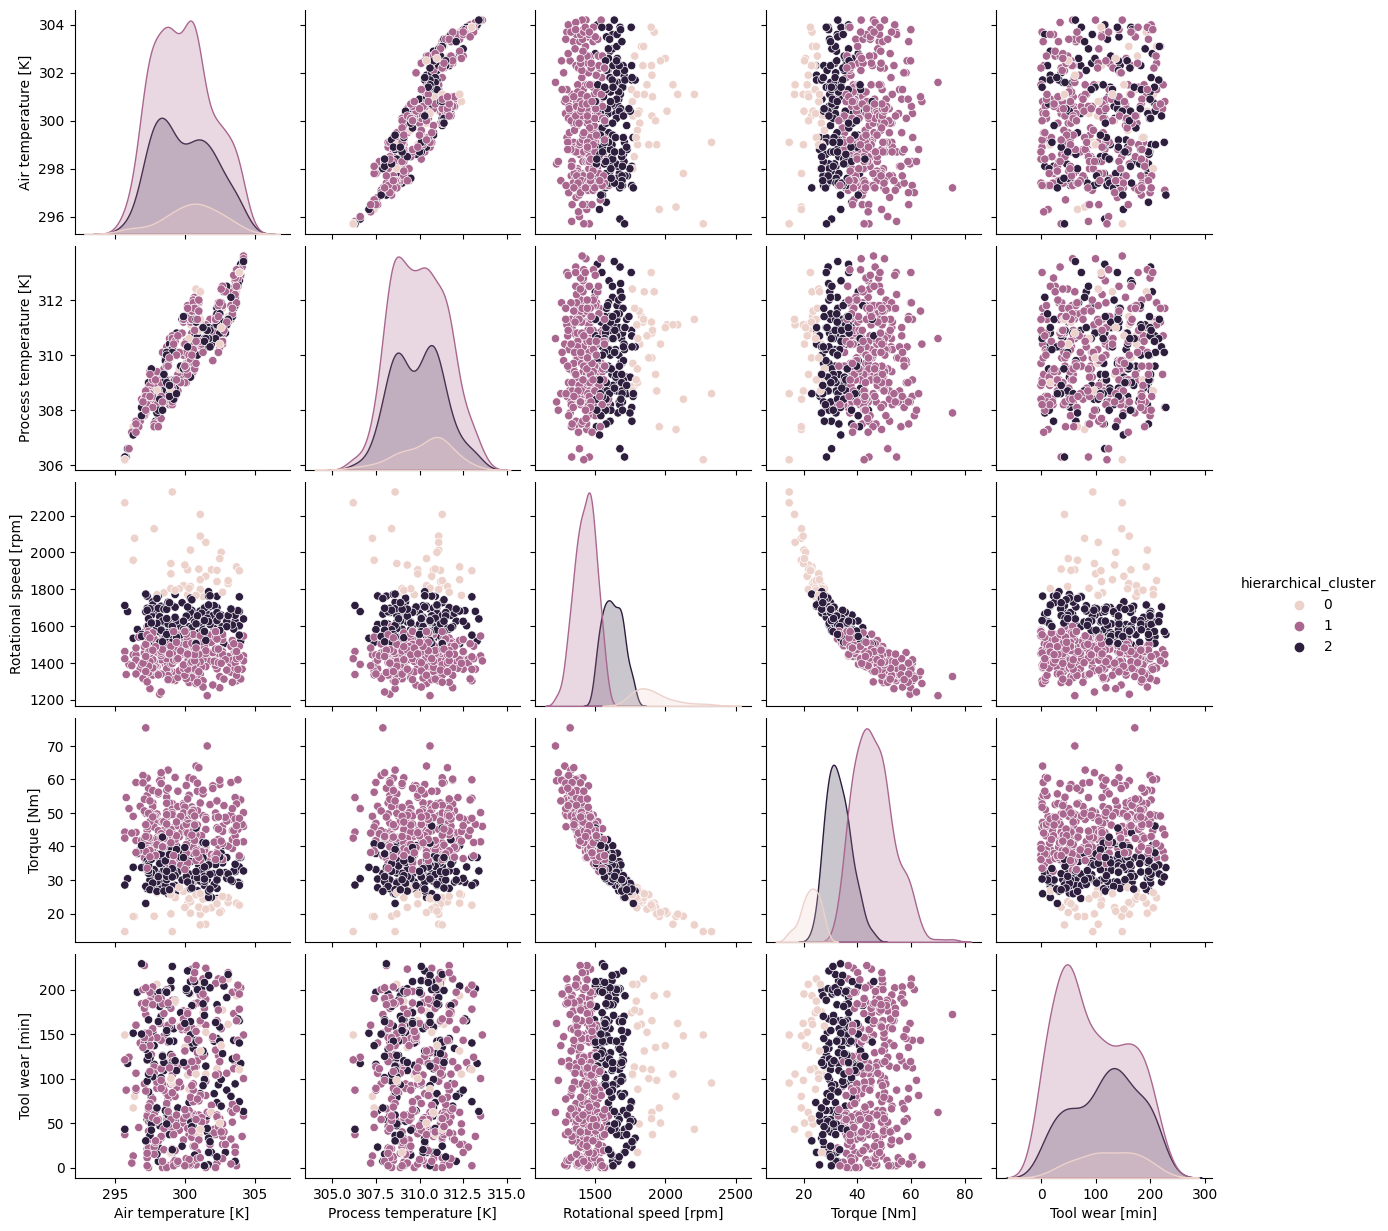

In [20]:
plt.figure(figsize=(10, 8))

sns.pairplot(X.sample(frac=0.05), hue="hierarchical_cluster", vars=["Air temperature [K]", "Process temperature [K]", "Rotational speed [rpm]", "Torque [Nm]", "Tool wear [min]"])
plt.show()